# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import plotly.express as px
import plotly.graph_objects as go

# Load Dataset

In [7]:
df = pd.read_csv("/content/sample_data/credit_card_fraud_10k[1].csv")
print(df.head())
print(df.info())
print(df.isnull().sum())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

# Remove Duplicate Records

In [9]:
df = df.drop_duplicates()
print("Dataset Shape:", df.shape)
print(df.describe())

Dataset Shape: (10000, 10)
       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
mi

# Fraud vs Normal Transaction Count

In [12]:
fraud_count = df['is_fraud'].value_counts()
print(fraud_count)

is_fraud
0    9849
1     151
Name: count, dtype: int64


# Fraud Distribution Visualization

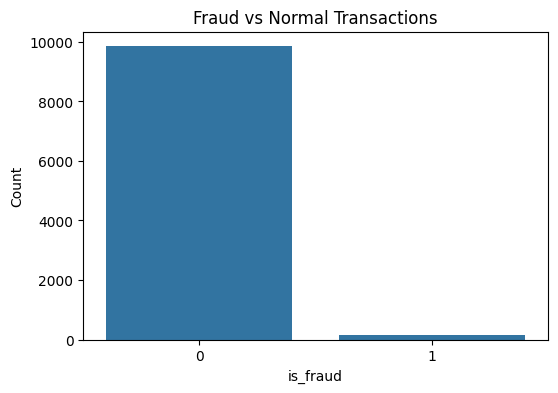

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

# Transaction Amount Distribution

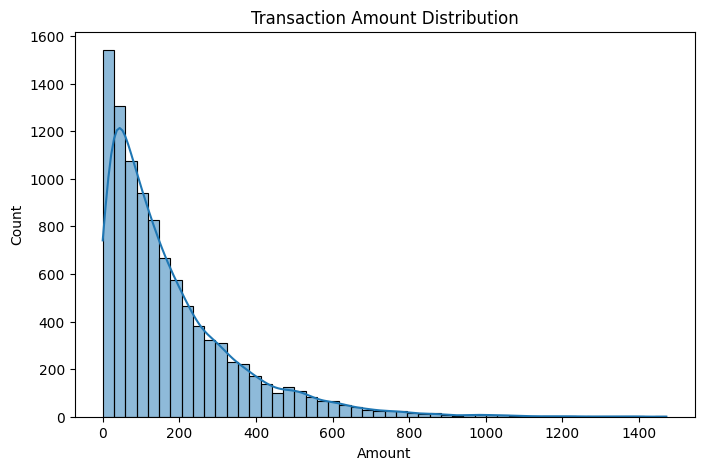

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.show()

# Boxplot for Outlier Detection

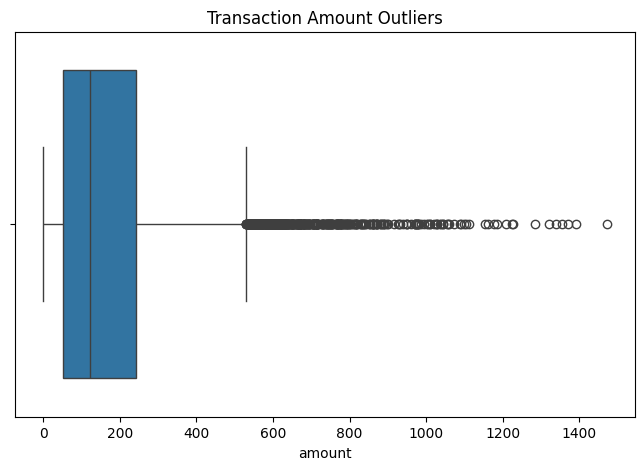

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Outliers")
plt.show()

# Correlation Heatmap

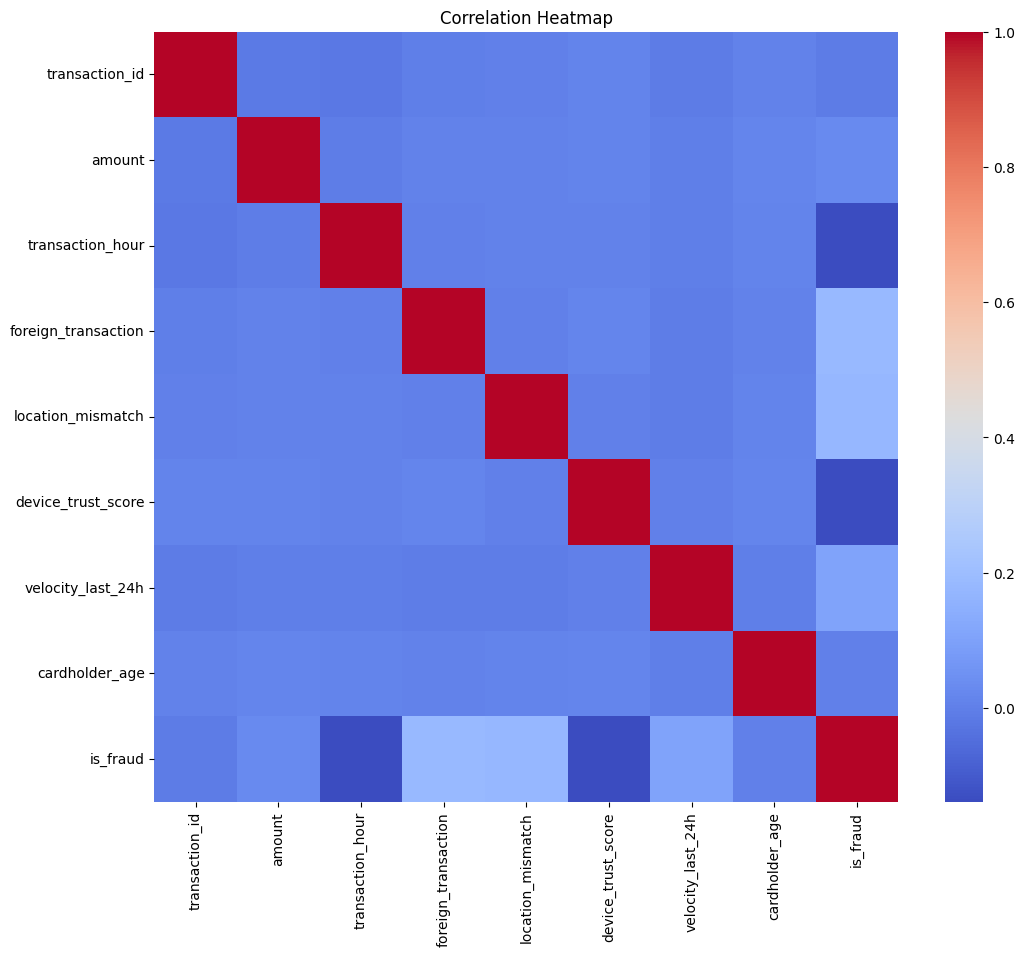

In [22]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Fraud vs Transaction Amount Analysis

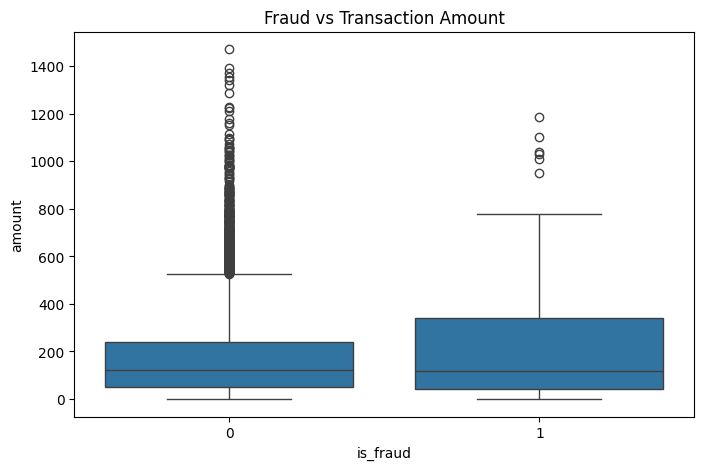

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

# Risk Analysis Function

In [25]:
def risk_category(amount):
    if amount < 100:
        return "Low Risk"
    elif amount < 1000:
        return "Medium Risk"
    else:
        return "High Risk"

# Create Risk Level Column

In [29]:
df['Risk_Level'] = df['amount'].apply(risk_category)

print(df['Risk_Level'].value_counts())
X = df[['transaction_hour']]
y = df['amount']

Risk_Level
Medium Risk    5627
Low Risk       4338
High Risk        35
Name: count, dtype: int64


# Split Training and Testing Data

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Linear Regression Model

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# R² Score

In [33]:
score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: -0.0002134551260764006


# Residual Analysis

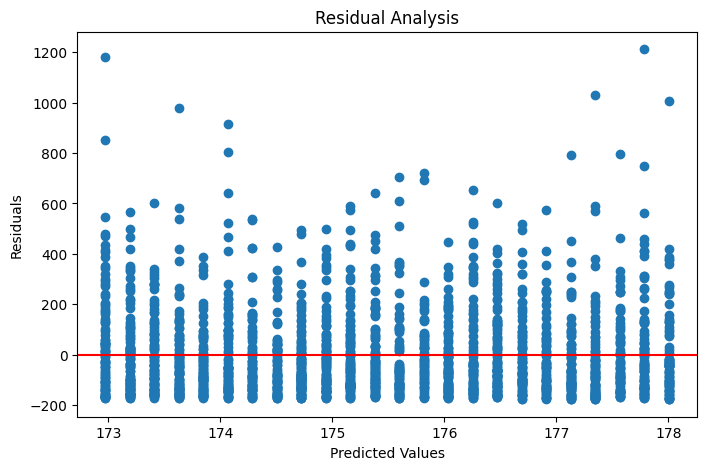

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='r')

plt.title("Residual Analysis")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

# Plotly Fraud Distribution Dashboard

In [36]:
fig1 = px.histogram(
    df,
    x='is_fraud',
    title='Fraud vs Normal Transactions'
)

fig1.show()

# Plotly Transaction Amount Distribution

In [38]:
fig2 = px.histogram(
    df,
    x='amount',
    nbins=50,
    title='Transaction Amount Distribution'
)

fig2.show()

# Scatter Plot

In [40]:
fig3 = px.scatter(
    df,
    x='transaction_hour',
    y='amount',
    color='is_fraud',
    title='Transaction Time vs Amount'
)

fig3.show()

# Risk Level Distribution

In [41]:
fig4 = px.histogram(
    df,
    x='Risk_Level',
    color='Risk_Level',
    title='Risk Level Distribution'
)

fig4.show()

# Output Message

In [42]:
print("Project Execution Completed Successfully")

Project Execution Completed Successfully
